<a href="https://colab.research.google.com/github/weleba77/machine-Leaning-/blob/main/magic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

In [7]:
# @title Default title text
cola = ["fLength","fWidth","fSize","fConc","fConc1","fAsym","fM3Long","fM3Trans", "fAlpha","fDist","class"]
df = pd.read_csv("magic04.data",names=cola)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [8]:
df["class"].unique()

array(['g', 'h'], dtype=object)

In [9]:
df["class"] = (df["class"] == "g").astype(int)

In [10]:
df["class"].unique()

array([1, 0])

In [11]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


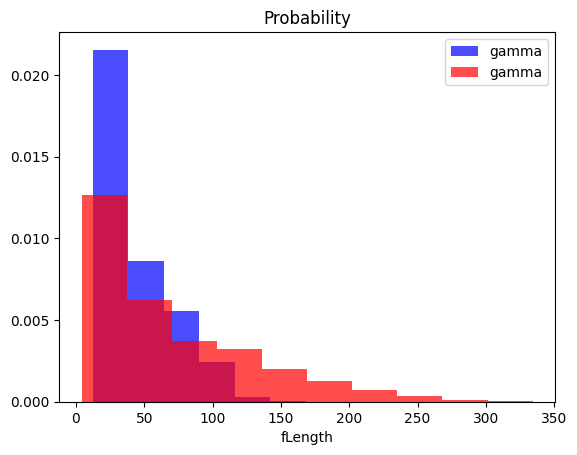

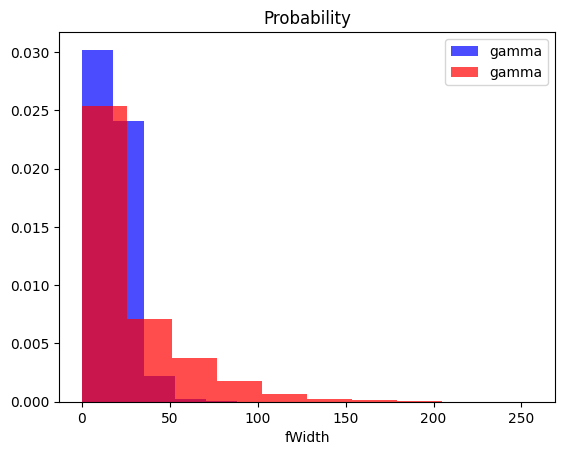

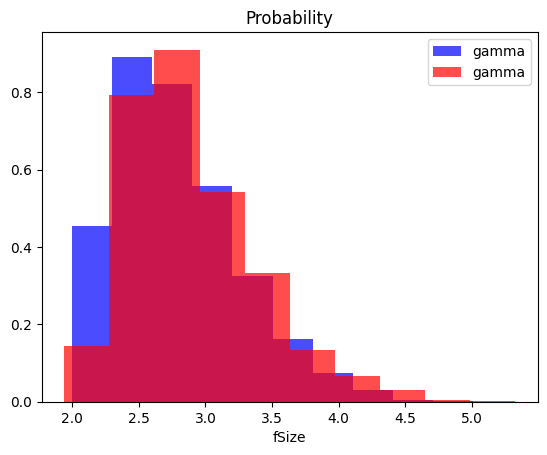

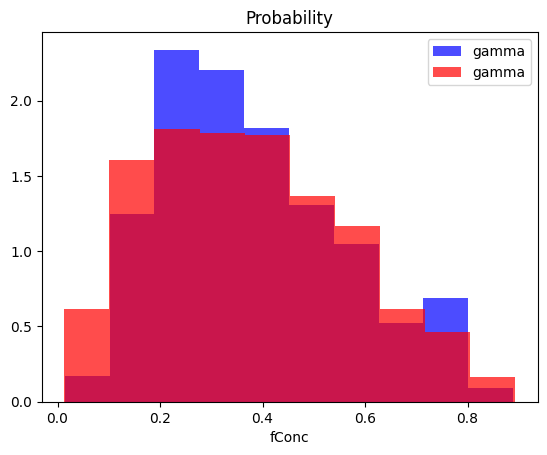

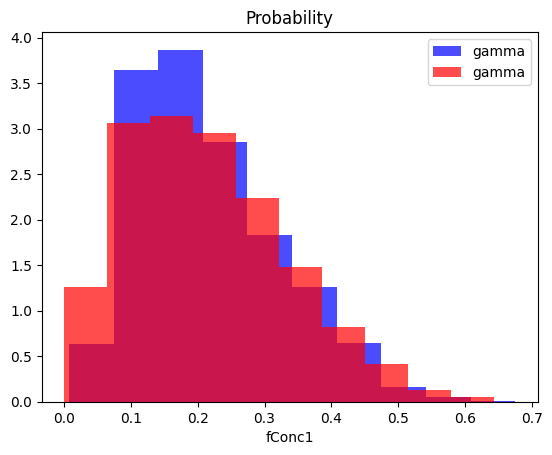

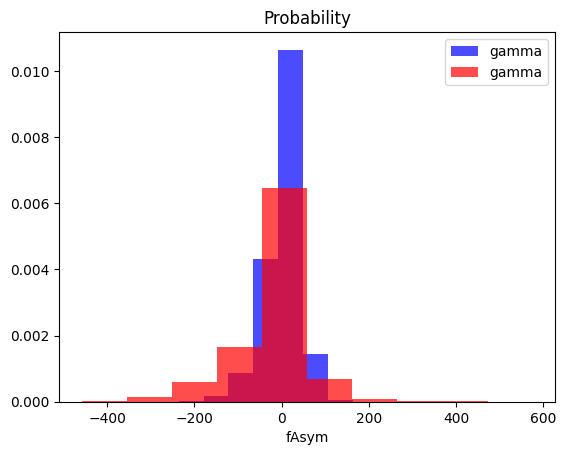

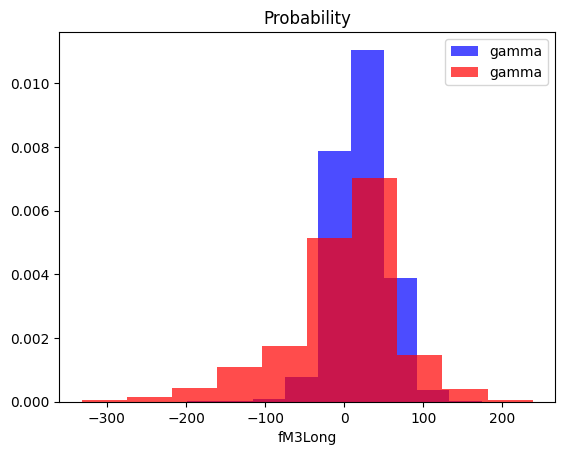

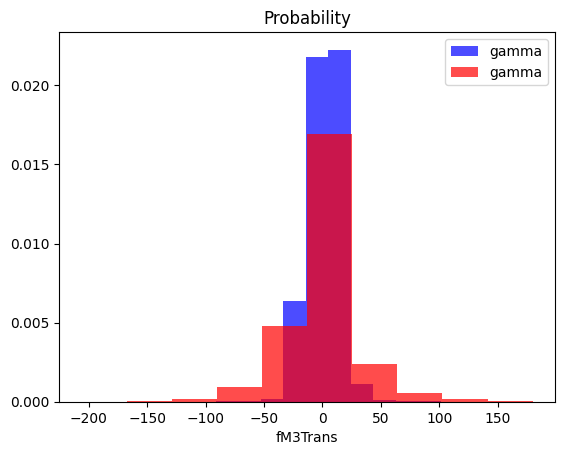

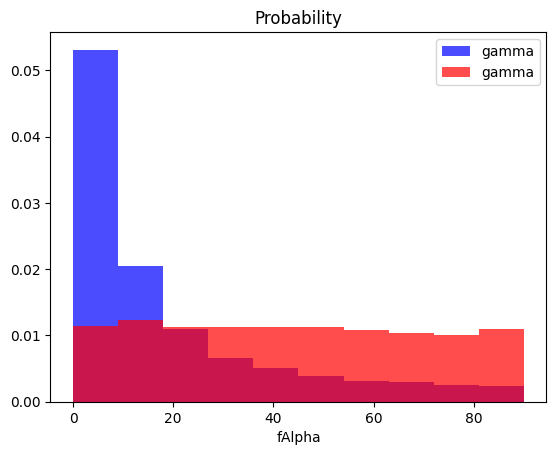

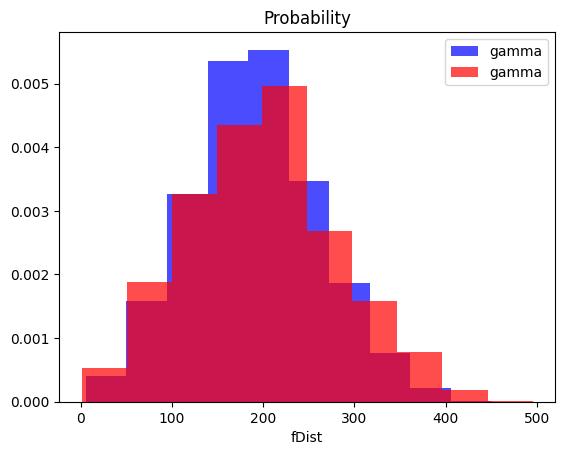

In [12]:
for label in cola[:-1]:
  plt.hist(df[df["class"]==1][label], color= "blue", label="gamma",alpha=0.7,density=True)
  plt.hist(df[df["class"]==0][label], color= "red", label="gamma",alpha=0.7,density=True)
  plt.title("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

Train, validation, test dataset

In [15]:
train, valid, test = np.split(df.sample(frac=1),[int(0.6*len(df)), int(0.8*len(df))])

In [14]:
train, x_train, y_train = scale_dateset(train,oversample=True)

NameError: name 'scale_dateset' is not defined

In [17]:
def scale_dataset (dataframe, oversample= False):
  x= dataframe[dataframe.columns[:-1]].values
  y= dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)


  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x,y)

  data = np.hstack((x,np.reshape(y,(-1,1))))

  return data, x, y

In [20]:
train, temp = train_test_split(df, test_size=0.3, random_state=42)
valid, test = train_test_split(temp, test_size=0.5, random_state=42)

In [21]:
train, x_train,y_train = scale_dataset(train,oversample = True)
valid, x_valid, y_valid = scale_dataset(valid, oversample=False)
test, x_test, y_test = scale_dataset(test, oversample=False)


KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


In [23]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)

KNeighborsClassifier()

In [24]:
y_pred = knn_model.predict(x_test)

In [25]:
y_pred

array([0, 1, 1, ..., 1, 0, 1])

In [26]:
y_test

array([0, 1, 0, ..., 1, 1, 1])

In [27]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.74      0.75      1007
           1       0.86      0.87      0.86      1846

    accuracy                           0.82      2853
   macro avg       0.81      0.81      0.81      2853
weighted avg       0.82      0.82      0.82      2853



In [28]:
from sklearn.naive_bayes import GaussianNB

In [29]:
nb_model = GaussianNB()
nb_model = nb_model.fit(x_train, y_train)

In [30]:
y_pred = nb_model.predict(x_test)

In [31]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.38      0.50      1007
           1       0.73      0.92      0.82      1846

    accuracy                           0.73      2853
   macro avg       0.73      0.65      0.66      2853
weighted avg       0.73      0.73      0.70      2853



**logictic regation**

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(x_train,y_train)

In [34]:
y_pred = lg_model.predict(x_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.72      0.71      1007
           1       0.85      0.84      0.84      1846

    accuracy                           0.80      2853
   macro avg       0.78      0.78      0.78      2853
weighted avg       0.80      0.80      0.80      2853



In [35]:
from sklearn.svm import SVC

In [36]:
svm_model = SVC()
svm_model = svm_model.fit(x_train,y_train)

In [37]:
y_pred = svm_model.predict(x_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1007
           1       0.90      0.90      0.90      1846

    accuracy                           0.87      2853
   macro avg       0.86      0.86      0.86      2853
weighted avg       0.87      0.87      0.87      2853



**neural network**

In [38]:
import tensorflow as tf

In [61]:
def plot_accuracy(history):
  plt.plot(history.history['accuracy'], label = 'accuracy')
  plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
  plt.xlabel('epoch')
  plt.ylabel('accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

In [52]:
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu",input_shape=(10,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss= "binary_crossentropy", metrics = ["accuracy"])

In [ ]:
histoty = nn_model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

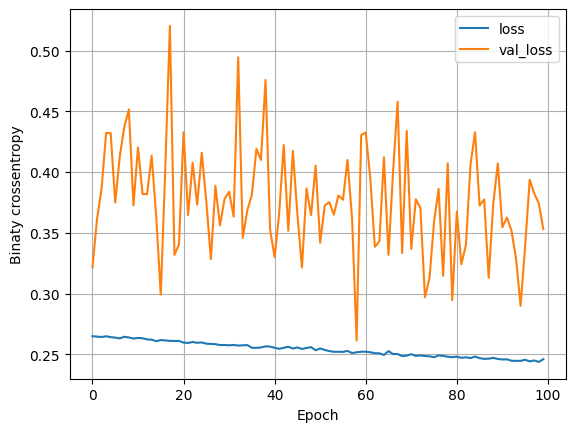

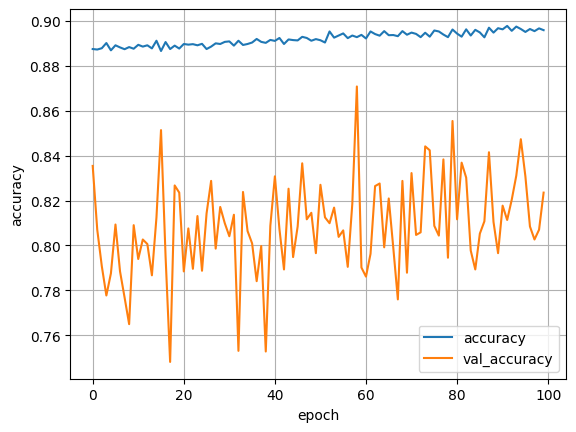

In [67]:
plot_loss(histoty)
plot_accuracy(his)

In [69]:
def train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes, activation="relu", input_shape=(10,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation="relu"),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = nn_model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    return nn_model, history


16 nodes, dropout 0, lr 0.01, batch size 32


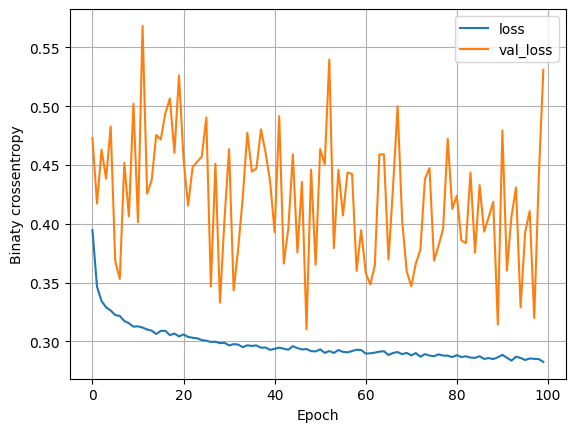

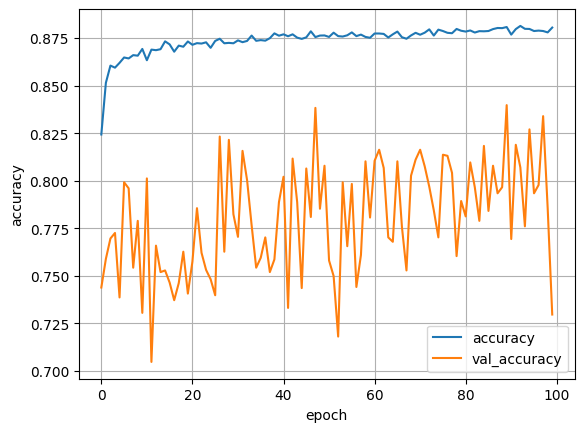

16 nodes, dropout 0, lr 0.01, batch size 64


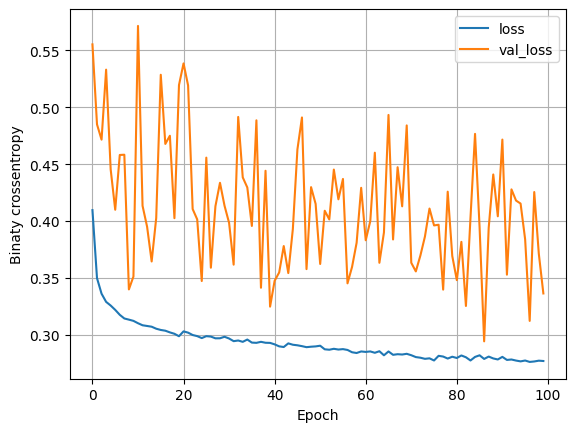

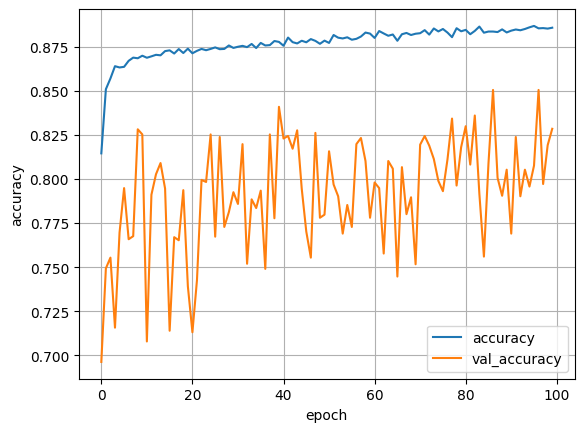

16 nodes, dropout 0, lr 0.01, batch size 128


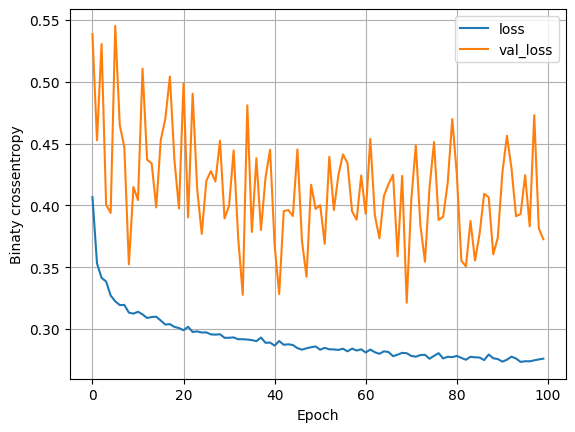

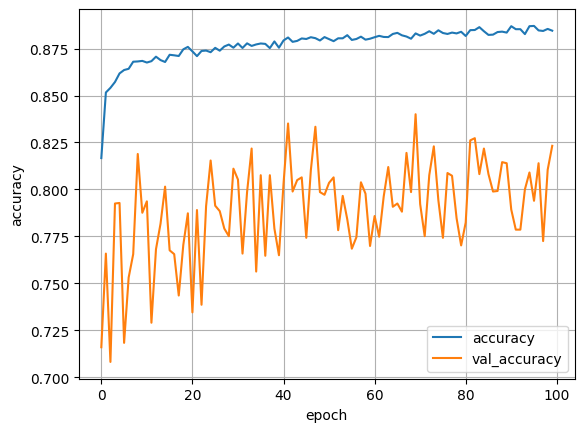

16 nodes, dropout 0, lr 0.005, batch size 32


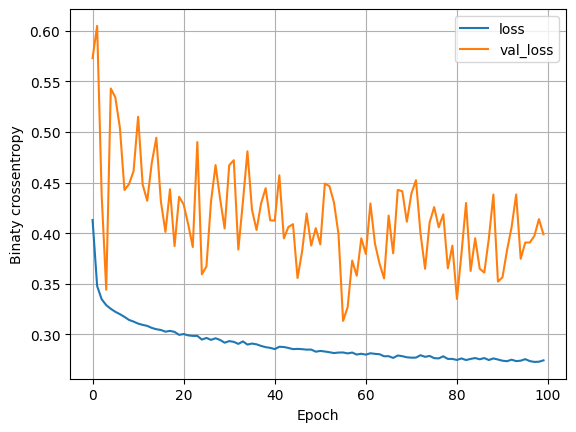

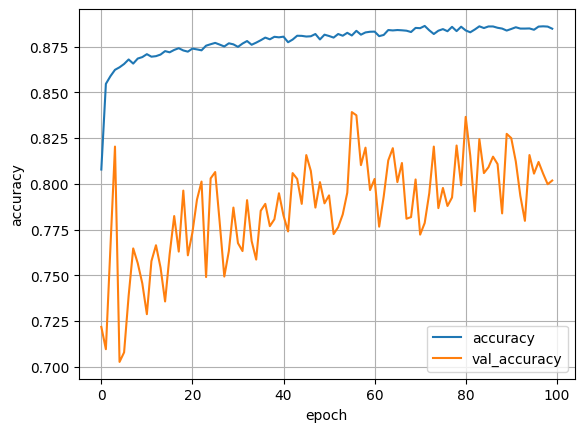

16 nodes, dropout 0, lr 0.005, batch size 64


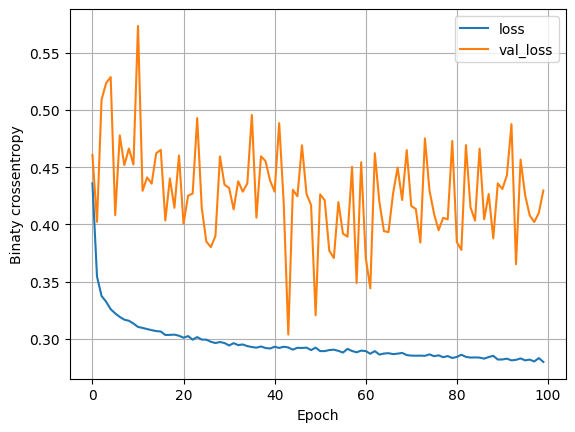

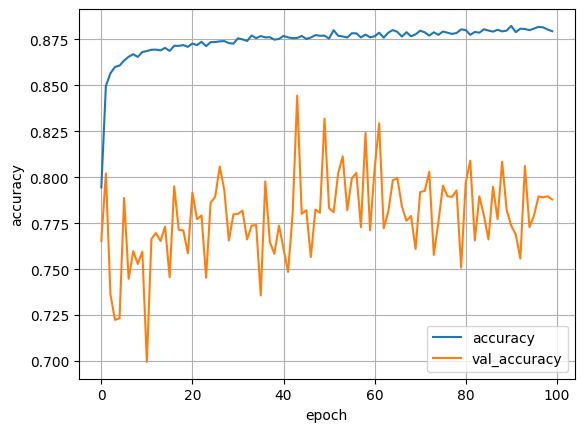

16 nodes, dropout 0, lr 0.005, batch size 128


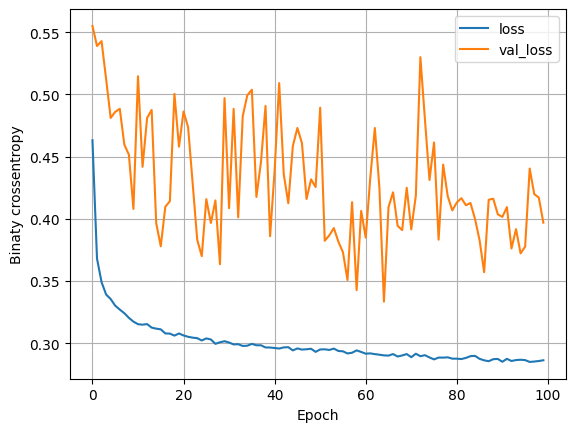

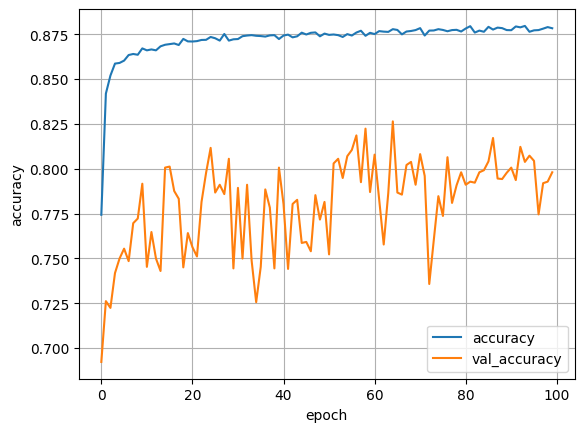

16 nodes, dropout 0, lr 0.001, batch size 32


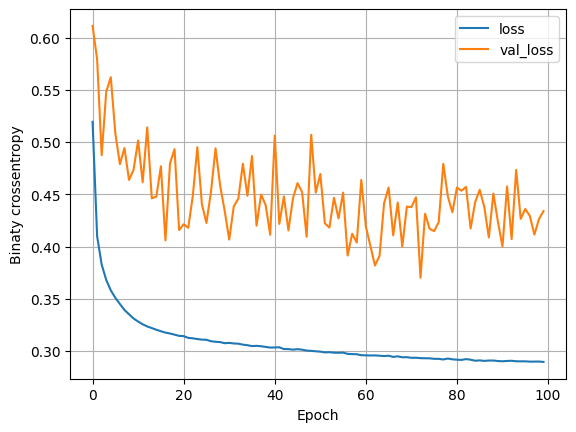

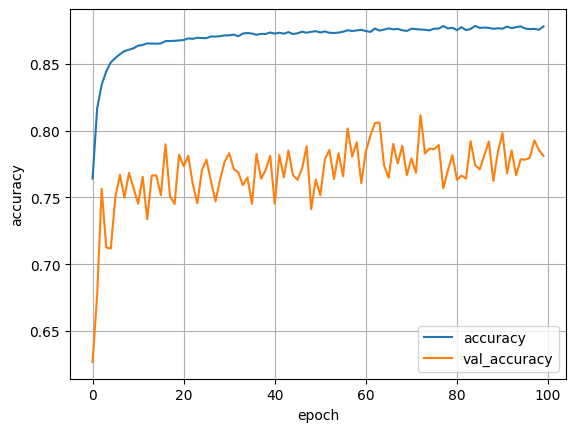

16 nodes, dropout 0, lr 0.001, batch size 64


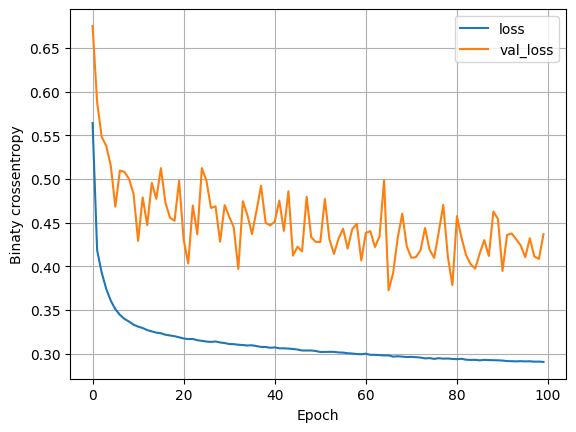

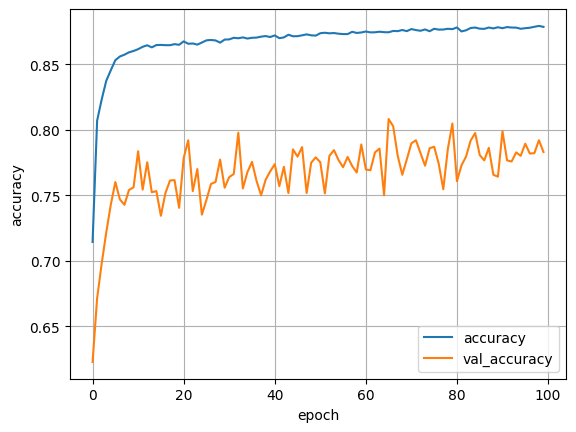

16 nodes, dropout 0, lr 0.001, batch size 128


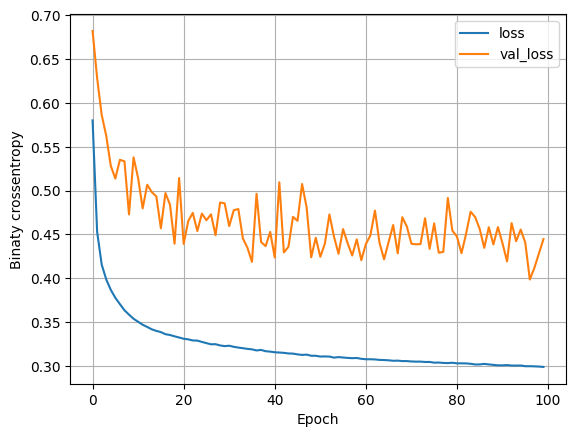

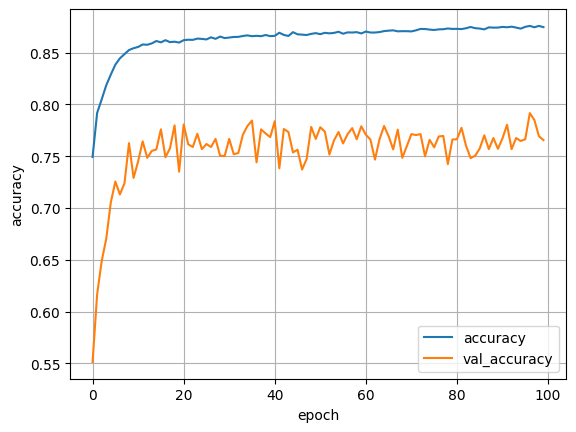

16 nodes, dropout 0.2, lr 0.01, batch size 32


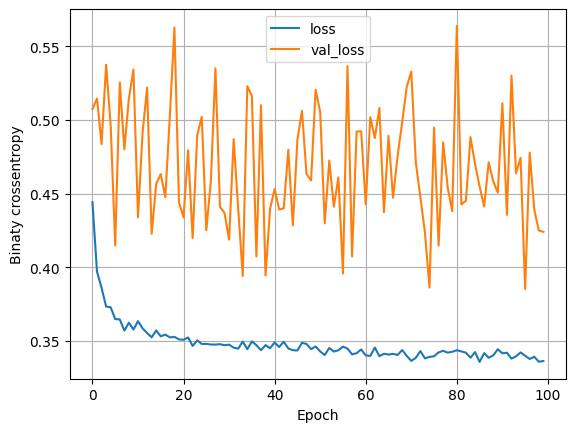

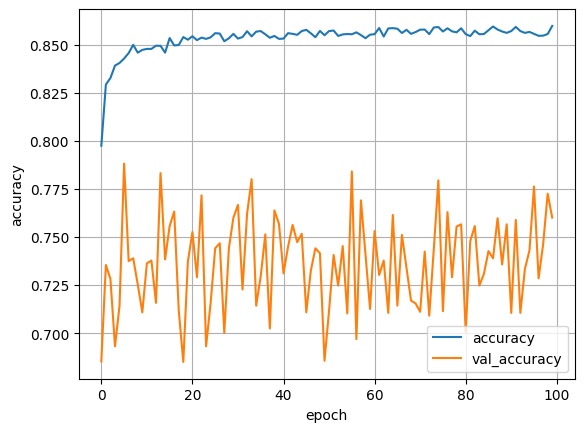

16 nodes, dropout 0.2, lr 0.01, batch size 64


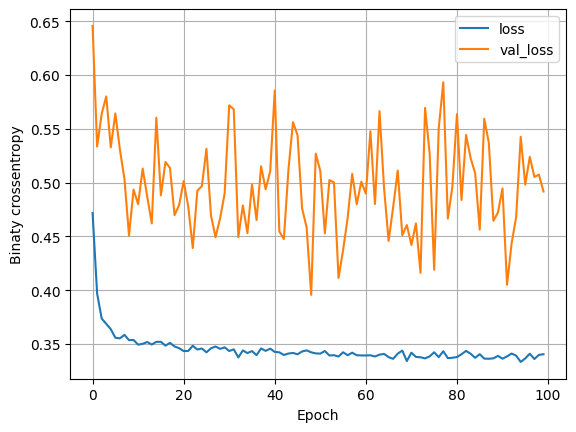

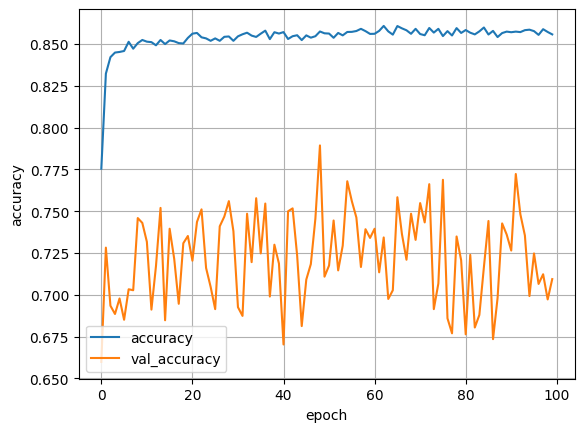

16 nodes, dropout 0.2, lr 0.01, batch size 128


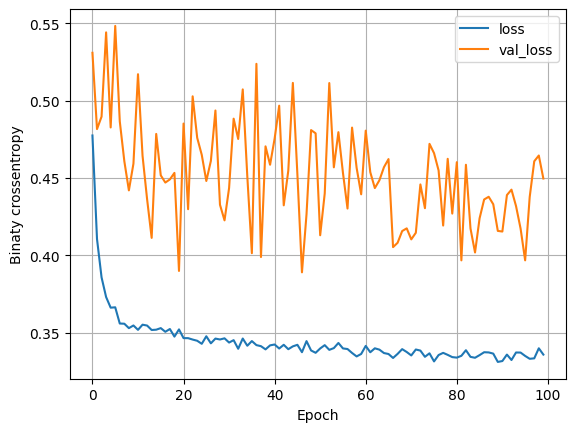

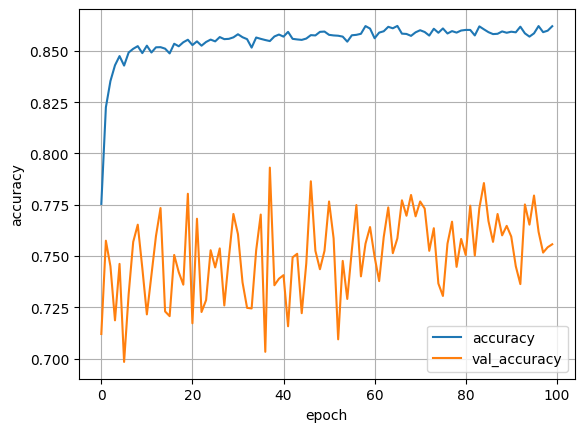

16 nodes, dropout 0.2, lr 0.005, batch size 32


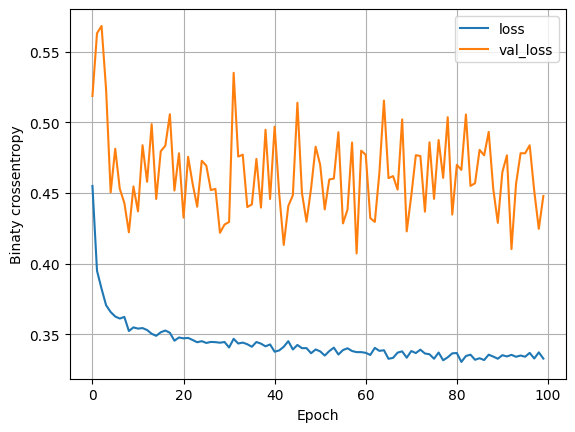

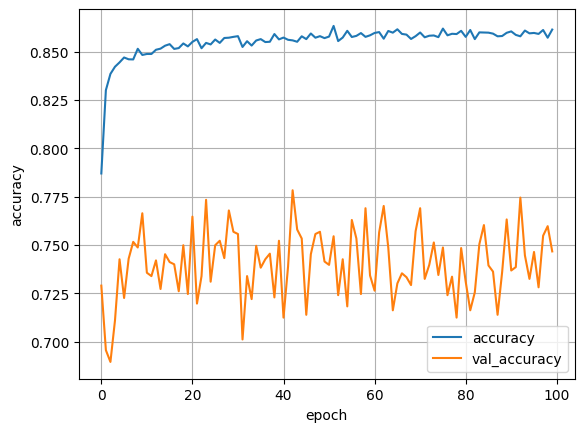

16 nodes, dropout 0.2, lr 0.005, batch size 64


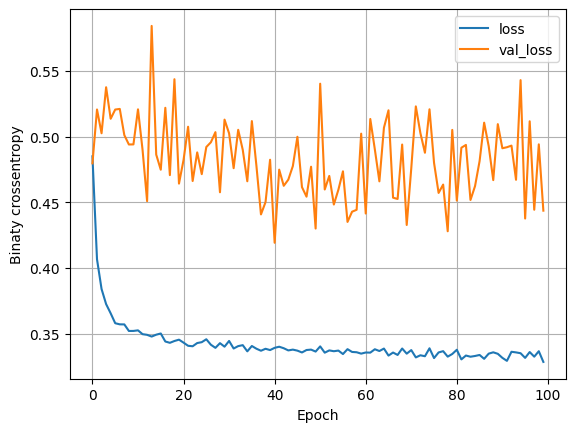

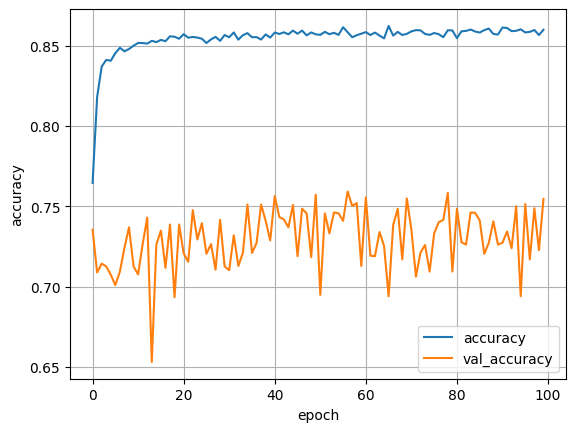

16 nodes, dropout 0.2, lr 0.005, batch size 128


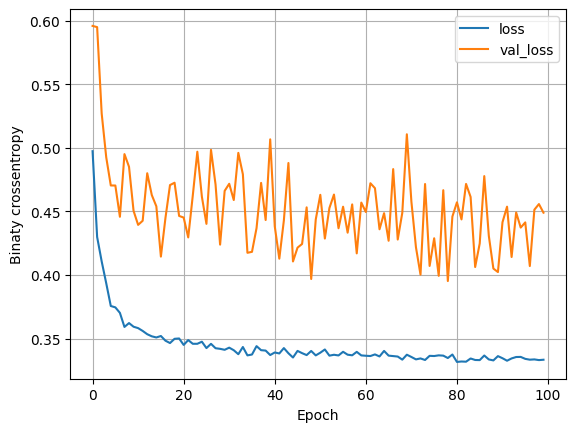

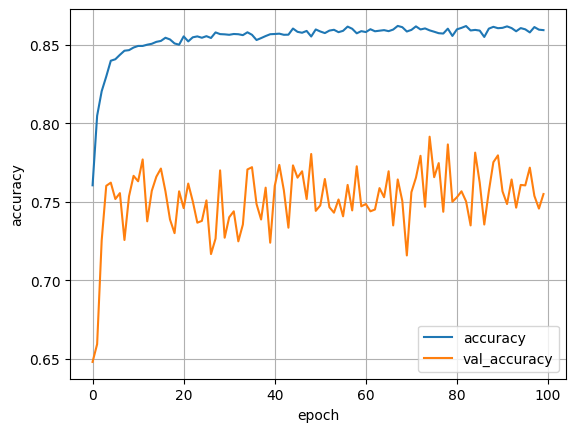

16 nodes, dropout 0.2, lr 0.001, batch size 32


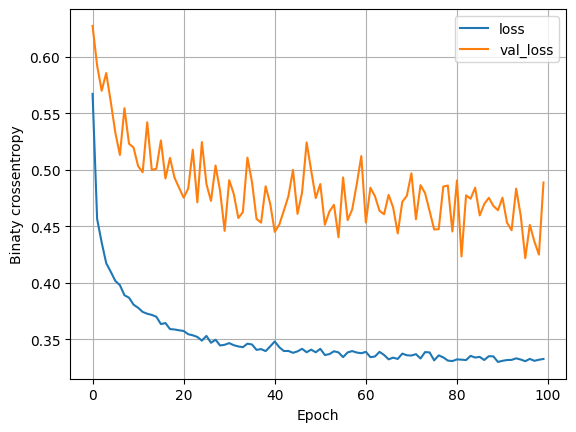

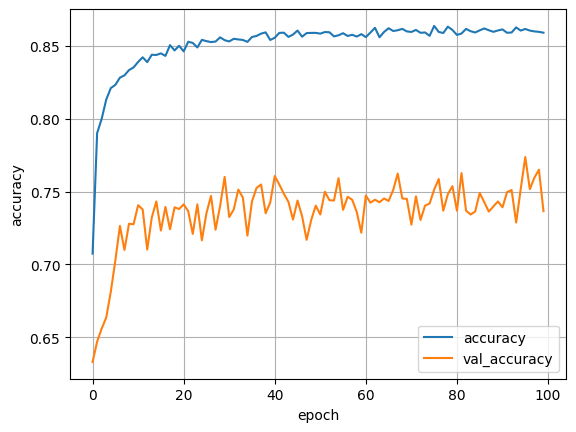

16 nodes, dropout 0.2, lr 0.001, batch size 64


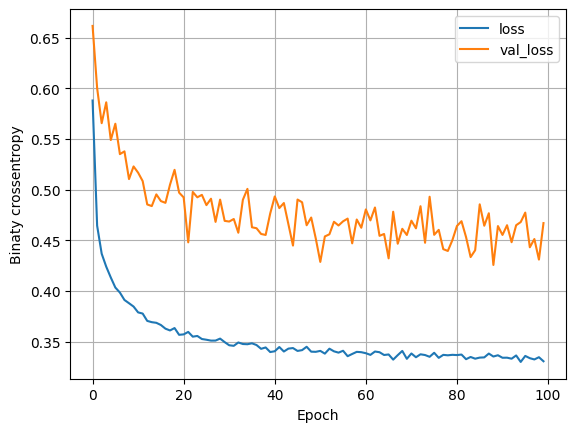

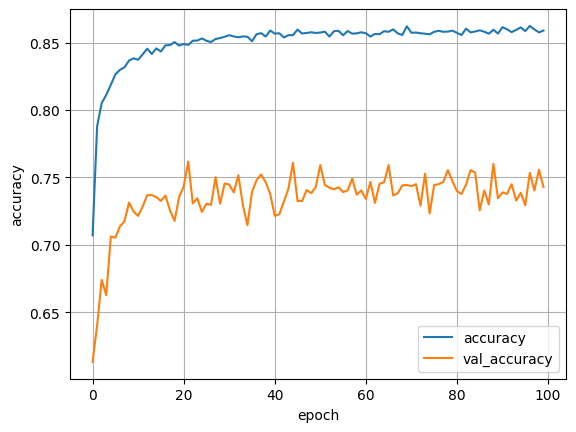

16 nodes, dropout 0.2, lr 0.001, batch size 128


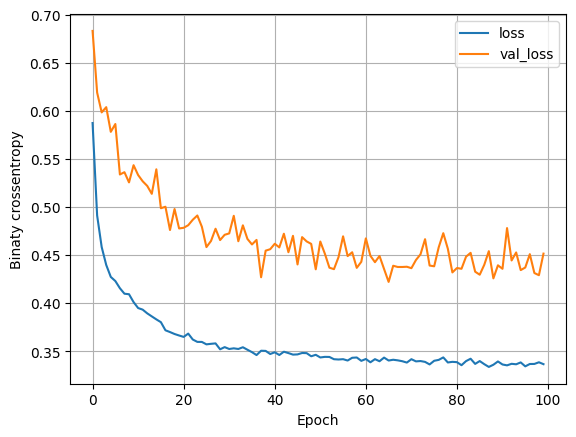

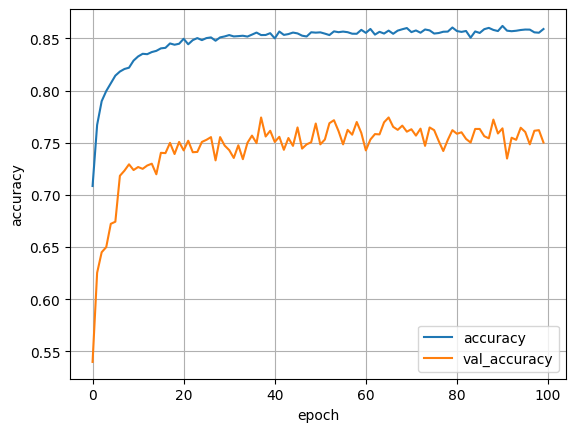

32 nodes, dropout 0, lr 0.01, batch size 32


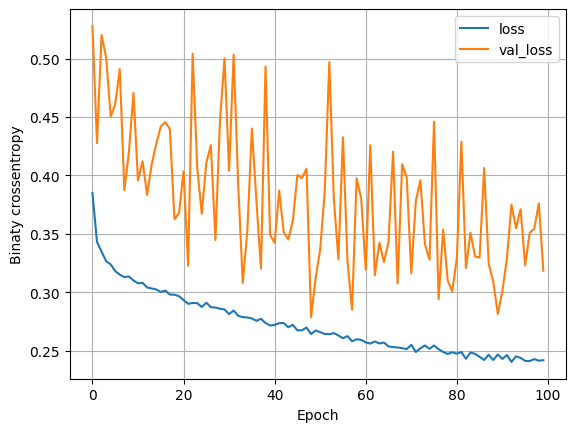

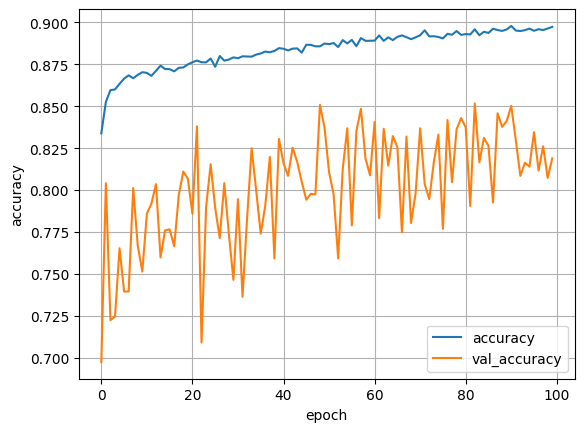

32 nodes, dropout 0, lr 0.01, batch size 64


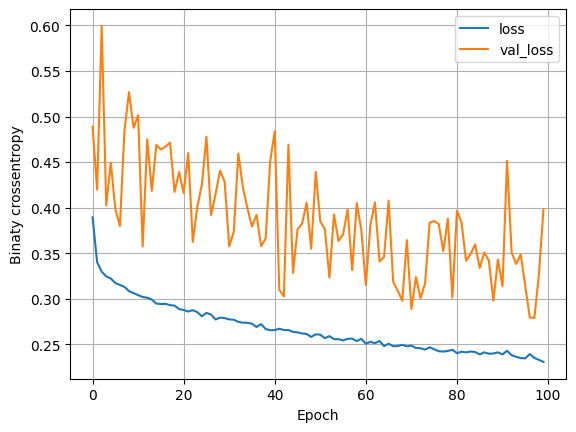

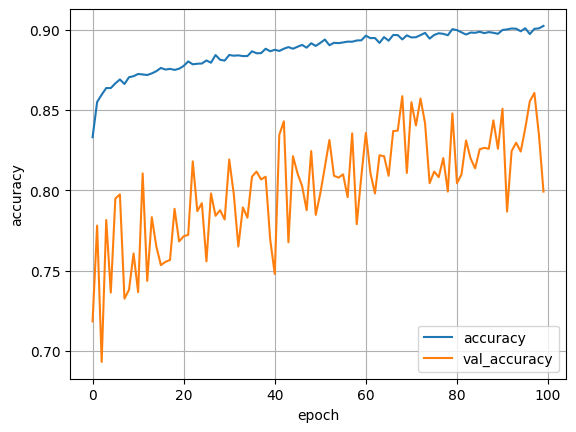

32 nodes, dropout 0, lr 0.01, batch size 128


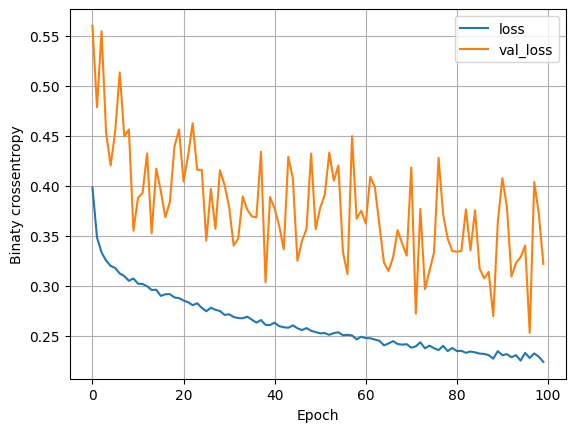

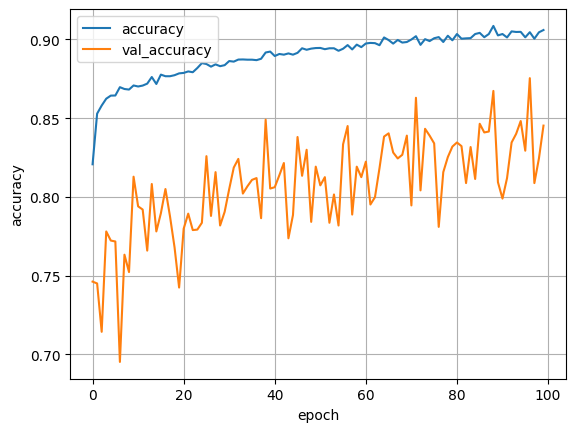

32 nodes, dropout 0, lr 0.005, batch size 32


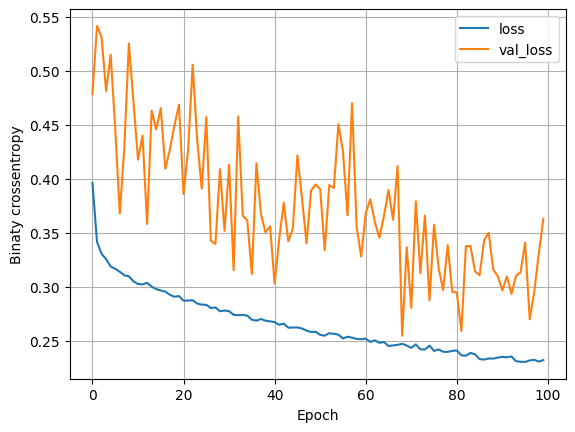

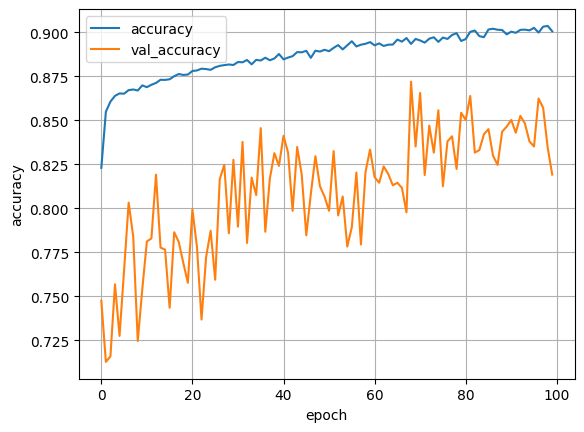

32 nodes, dropout 0, lr 0.005, batch size 64


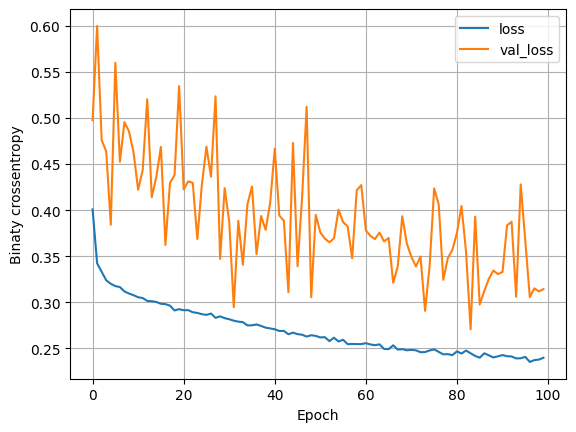

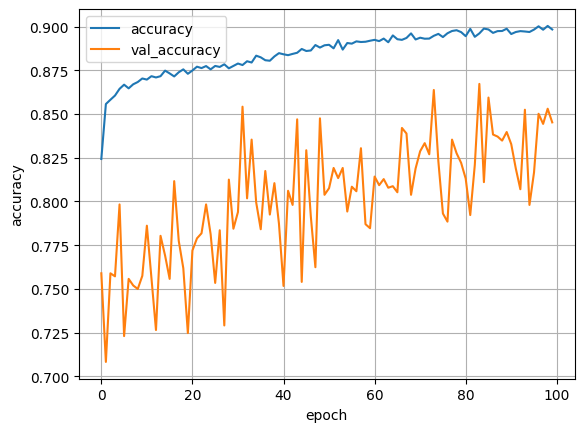

32 nodes, dropout 0, lr 0.005, batch size 128


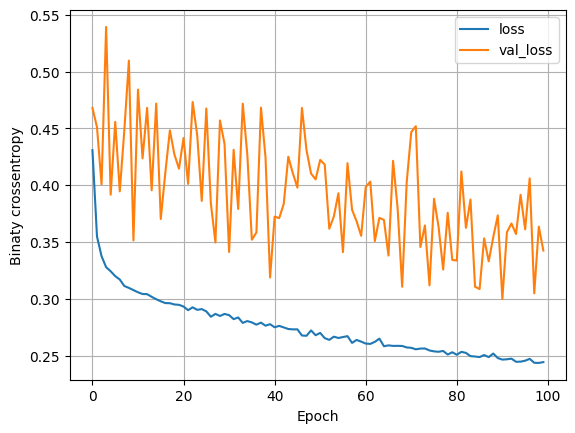

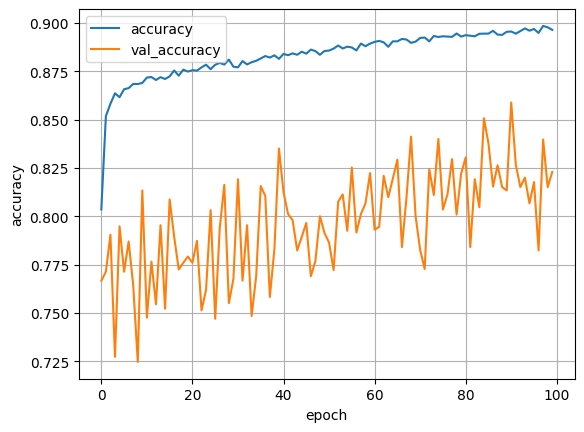

32 nodes, dropout 0, lr 0.001, batch size 32


In [ ]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 100

for num_nodes in [16, 32, 64]:
    for dropout_prob in [0, 0.2]:
        for lr in [0.01, 0.005, 0.001]:
            for batch_size in [32, 64, 128]:
                print(f"{num_nodes} nodes, dropout {dropout_prob}, lr {lr}, batch size {batch_size}")

                model, history = train_model(
                    x_train, y_train,
                    num_nodes, dropout_prob, lr, batch_size, epochs
                )

                plot_loss(history)
                plot_accuracy(history)

                val_loss, val_accuracy = model.evaluate(x_valid, y_valid, verbose=0)

                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_loss_model = model
